In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
df=pd.read_csv("customer_churn_clean_220k.csv")

In [18]:
df

,age,gender_male,is_senior_citizen,tenure_months,avg_monthly_usage_gb,support_tickets_last_6m,monthly_charges,payment_delay_ratio,has_internet_service,has_streaming_service,has_device_protection,contract_month_to_month,contract_one_year,contract_two_year,avg_charge_per_gb,high_support_contact,long_term_customer,engagement_score,churn
0,56,1,0,46,29.48,0,49.60,0.14,1,1,0,1,1,1,1.63,0,1,35.992,0
1,69,0,0,42,39.11,1,38.47,0.16,1,1,0,1,1,0,0.96,0,1,39.044,0
2,46,0,0,71,7.86,0,52.25,0.13,1,1,0,0,0,0,5.90,0,1,32.344,1
3,32,1,0,48,12.11,1,40.38,0.10,1,1,1,1,0,1,3.08,0,1,39.444,0
4,60,1,0,11,18.56,2,48.13,0.03,1,1,0,0,0,0,2.46,0,0,24.624,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
219995,72,0,0,63,8.82,3,57.22,0.03,1,0,1,0,1,1,5.83,1,1,26.128,1
219996,67,0,0,20,20.48,0,78.64,0.12,0,0,0,0,0,0,3.66,0,0,12.192,0
219997,65,1,0,44,30.82,0,57.84,0.33,1,1,0,1,1,1,1.82,0,1,36.128,0
219998,59,0,0,44,29.48,1,62.52,0.36,1,1,0,0,0,0,2.05,0,1,35.592,1


In [19]:
# Settings
plt.style.use("seaborn-v0_8")
sns.set_palette("Set2")
plt.rcParams["figure.figsize"] = (10, 6)

In [20]:
df.head()

,age,gender_male,is_senior_citizen,tenure_months,avg_monthly_usage_gb,support_tickets_last_6m,monthly_charges,payment_delay_ratio,has_internet_service,has_streaming_service,has_device_protection,contract_month_to_month,contract_one_year,contract_two_year,avg_charge_per_gb,high_support_contact,long_term_customer,engagement_score,churn
0,56,1,0,46,29.48,0,49.60,0.14,1,1,0,1,1,1,1.63,0,1,35.992,0
1,69,0,0,42,39.11,1,38.47,0.16,1,1,0,1,1,0,0.96,0,1,39.044,0
2,46,0,0,71,7.86,0,52.25,0.13,1,1,0,0,0,0,5.90,0,1,32.344,1
3,32,1,0,48,12.11,1,40.38,0.10,1,1,1,1,0,1,3.08,0,1,39.444,0
4,60,1,0,11,18.56,2,48.13,0.03,1,1,0,0,0,0,2.46,0,0,24.624,0


In [21]:
df.shape


(220000, 19)

In [22]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220000 entries, 0 to 219999
Data columns (total 19 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   age                      220000 non-null  int64  
 1   gender_male              220000 non-null  int64  
 2   is_senior_citizen        220000 non-null  int64  
 3   tenure_months            220000 non-null  int64  
 4   avg_monthly_usage_gb     220000 non-null  float64
 5   support_tickets_last_6m  220000 non-null  int64  
 6   monthly_charges          220000 non-null  float64
 7   payment_delay_ratio      220000 non-null  float64
 8   has_internet_service     220000 non-null  int64  
 9   has_streaming_service    220000 non-null  int64  
 10  has_device_protection    220000 non-null  int64  
 11  contract_month_to_month  220000 non-null  int64  
 12  contract_one_year        220000 non-null  int64  
 13  contract_two_year        220000 non-null  int64  
 14  avg_

In [23]:
df.describe()


,age,gender_male,is_senior_citizen,tenure_months,avg_monthly_usage_gb,support_tickets_last_6m,monthly_charges,payment_delay_ratio,has_internet_service,has_streaming_service,has_device_protection,contract_month_to_month,contract_one_year,contract_two_year,avg_charge_per_gb,high_support_contact,long_term_customer,engagement_score,churn
count,220000.000000,220000.000000,220000.000000,220000.000000,220000.000000,220000.000000,220000.000000,220000.000000,220000.000000,220000.000000,220000.000000,220000.000000,220000.000000,220000.000000,220000.000000,220000.000000,220000.000000,220000.000000,220000.000000
mean,45.961205,0.548559,0.149941,35.986377,24.910382,1.196382,65.442100,0.200412,0.899632,0.601332,0.401073,0.549036,0.250195,0.198918,3.860555,0.120064,0.675259,30.192133,0.212200
std,16.428003,0.497638,0.357014,20.488617,15.703343,1.097279,24.245789,0.120825,0.300491,0.489625,0.490117,0.497591,0.433126,0.399187,3.863550,0.325037,0.468279,11.581519,0.408867
min,18.000000,0.000000,0.000000,1.000000,0.120000,0.000000,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.160000,0.000000,0.000000,0.700000,0.000000
25%,32.000000,0.000000,0.000000,18.000000,13.360000,0.000000,48.200000,0.110000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.670000,0.000000,0.000000,22.020000,0.000000
50%,46.000000,1.000000,0.000000,36.000000,21.690000,1.000000,65.090000,0.180000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,2.760000,0.000000,1.000000,30.224000,0.000000
75%,60.000000,1.000000,0.000000,54.000000,32.970000,2.000000,81.940000,0.270000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,4.640000,0.000000,1.000000,38.120000,0.000000
max,74.000000,1.000000,1.000000,71.000000,168.280000,8.000000,175.650000,0.840000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,92.900000,1.000000,1.000000,97.712000,1.000000


In [24]:
df.isnull().sum()


age                        0
gender_male                0
is_senior_citizen          0
tenure_months              0
avg_monthly_usage_gb       0
support_tickets_last_6m    0
monthly_charges            0
payment_delay_ratio        0
has_internet_service       0
has_streaming_service      0
has_device_protection      0
contract_month_to_month    0
contract_one_year          0
contract_two_year          0
avg_charge_per_gb          0
high_support_contact       0
long_term_customer         0
engagement_score           0
churn                      0
dtype: int64

Target variable distribution

In [25]:
df["churn"].value_counts()


churn
0    173316
1     46684
Name: count, dtype: int64

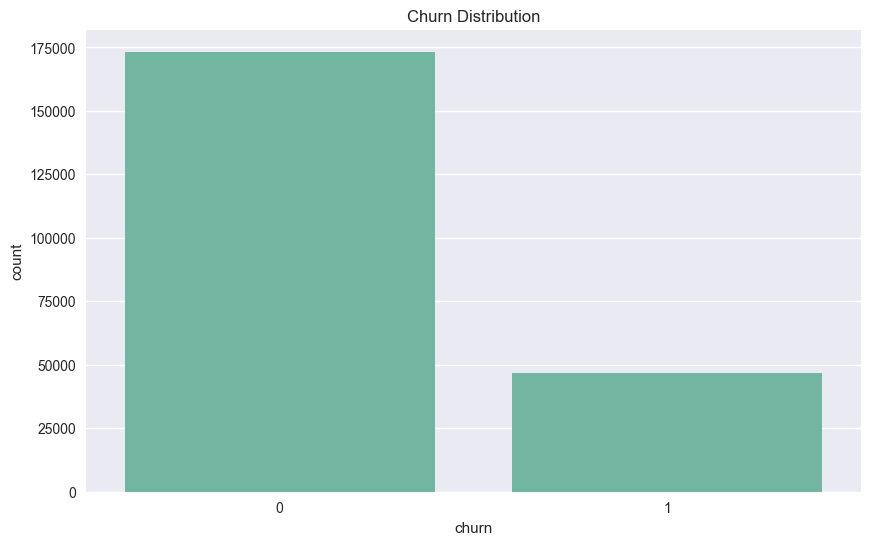

In [26]:
sns.countplot(x="churn", data=df)
plt.title("Churn Distribution")
plt.show()


Numerical feature distributions

In [27]:
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns
numerical_cols


Index(['age', 'gender_male', 'is_senior_citizen', 'tenure_months',
       'avg_monthly_usage_gb', 'support_tickets_last_6m', 'monthly_charges',
       'payment_delay_ratio', 'has_internet_service', 'has_streaming_service',
       'has_device_protection', 'contract_month_to_month', 'contract_one_year',
       'contract_two_year', 'avg_charge_per_gb', 'high_support_contact',
       'long_term_customer', 'engagement_score', 'churn'],
      dtype='object')

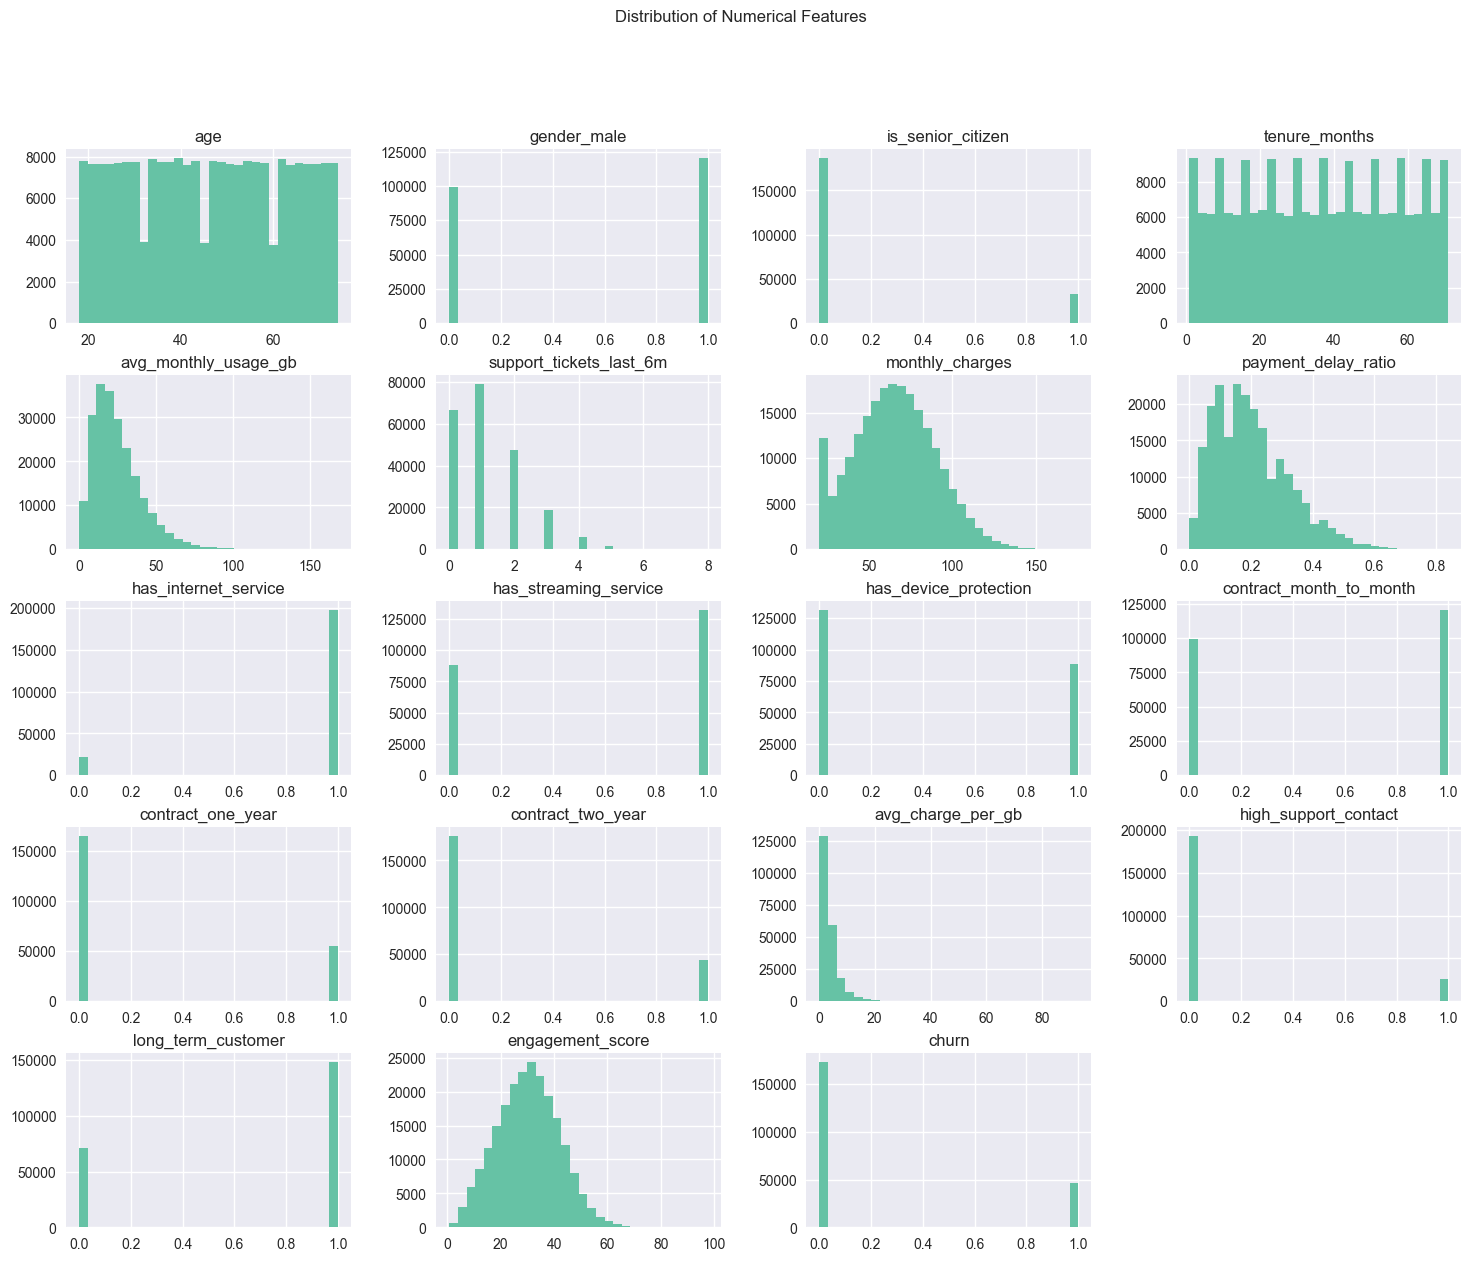

In [ ]:
df[numerical_cols].hist(bins=30, figsize=(18, 14))
plt.suptitle("Distribution of Numerical Features")
plt.show()


Correlation heatmap

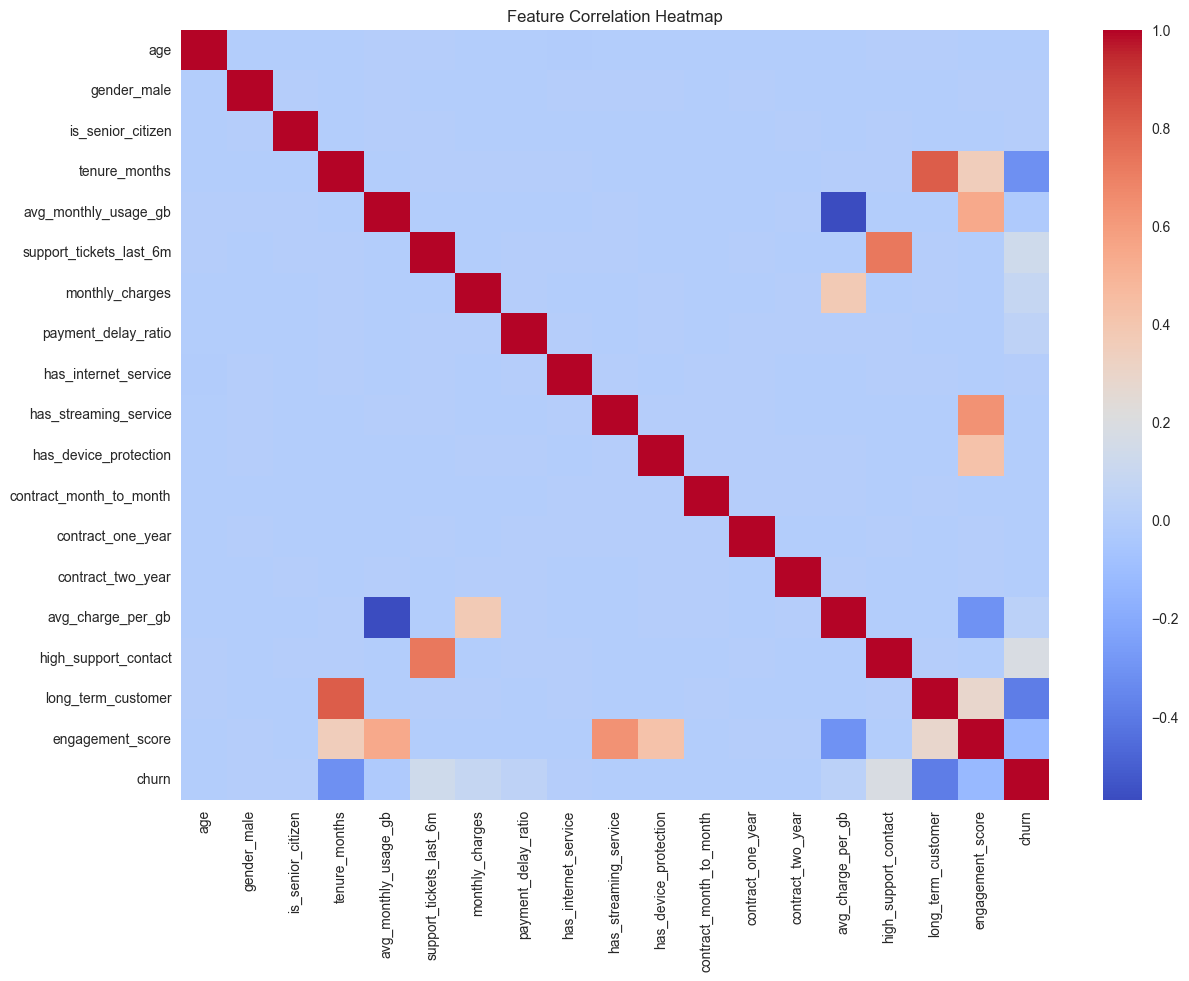

In [28]:
corr_matrix = df.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()


Churn vs Important Features

1.Tenure vs Churn

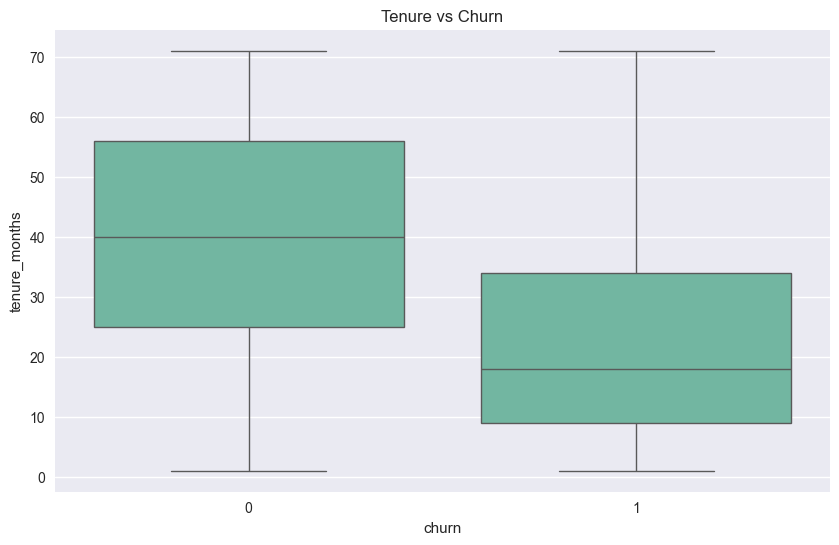

In [29]:
sns.boxplot(x="churn", y="tenure_months", data=df)
plt.title("Tenure vs Churn")
plt.show()


2.Monthly Charges vs Churn

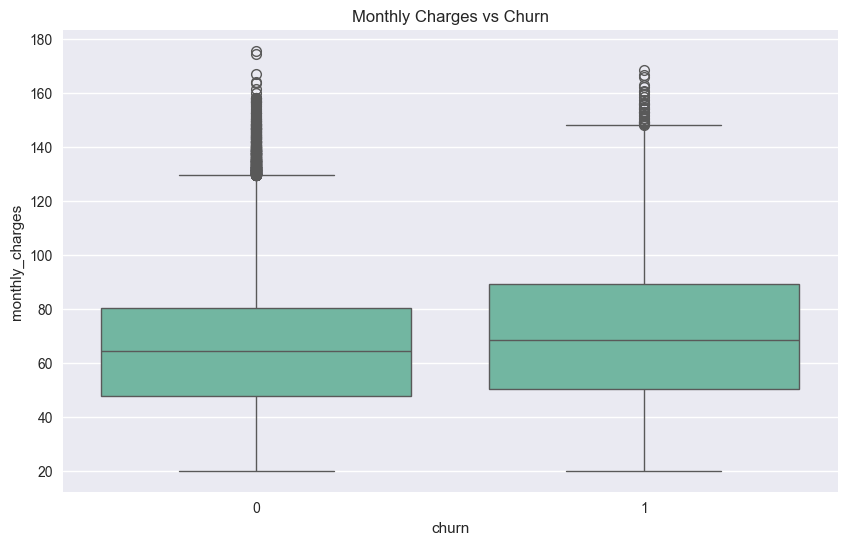

In [30]:
sns.boxplot(x="churn", y="monthly_charges", data=df)
plt.title("Monthly Charges vs Churn")
plt.show()


3.Support Tickets vs Churn

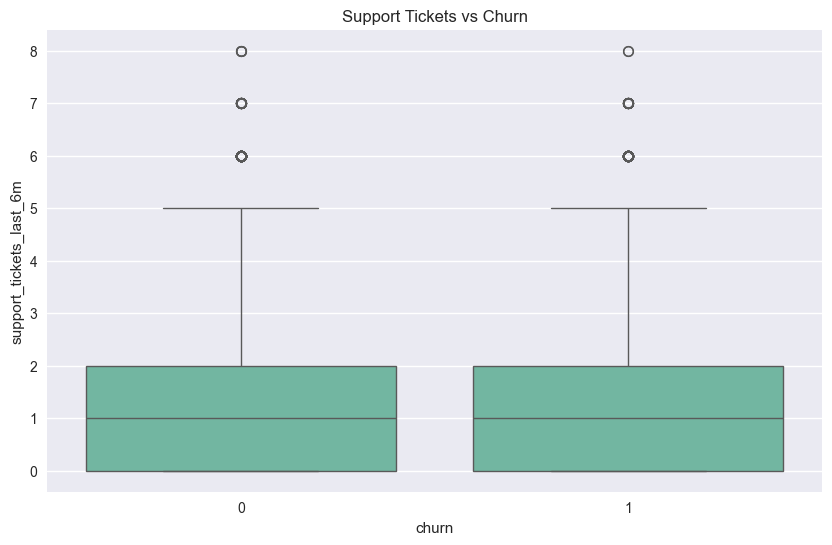

In [31]:
sns.boxplot(x="churn", y="support_tickets_last_6m", data=df)
plt.title("Support Tickets vs Churn")
plt.show()


Engineered features validation:

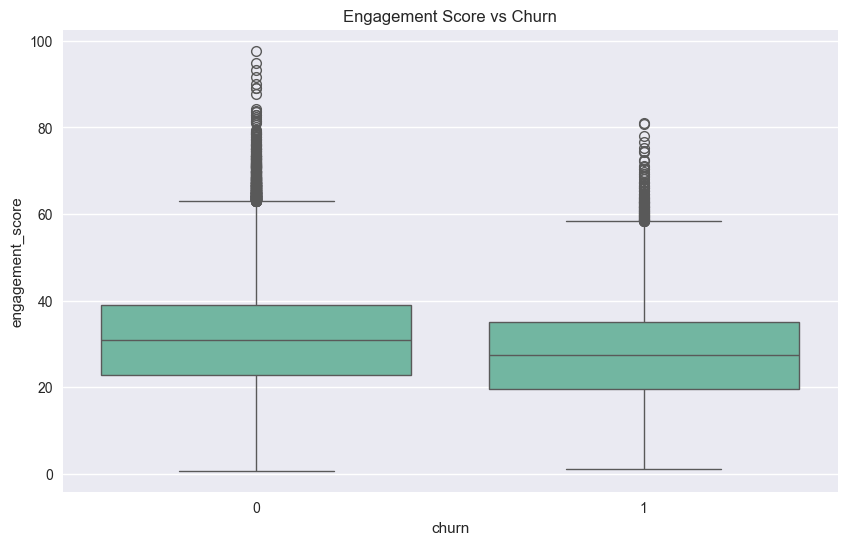

In [32]:
sns.boxplot(x="churn", y="engagement_score", data=df)
plt.title("Engagement Score vs Churn")
plt.show()


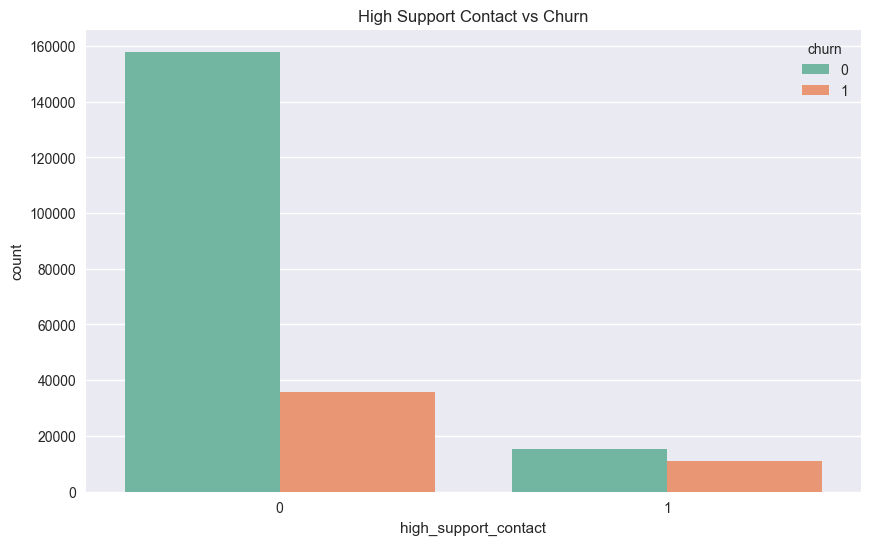

In [33]:
sns.countplot(x="high_support_contact", hue="churn", data=df)
plt.title("High Support Contact vs Churn")
plt.show()


Contract type impact on churn


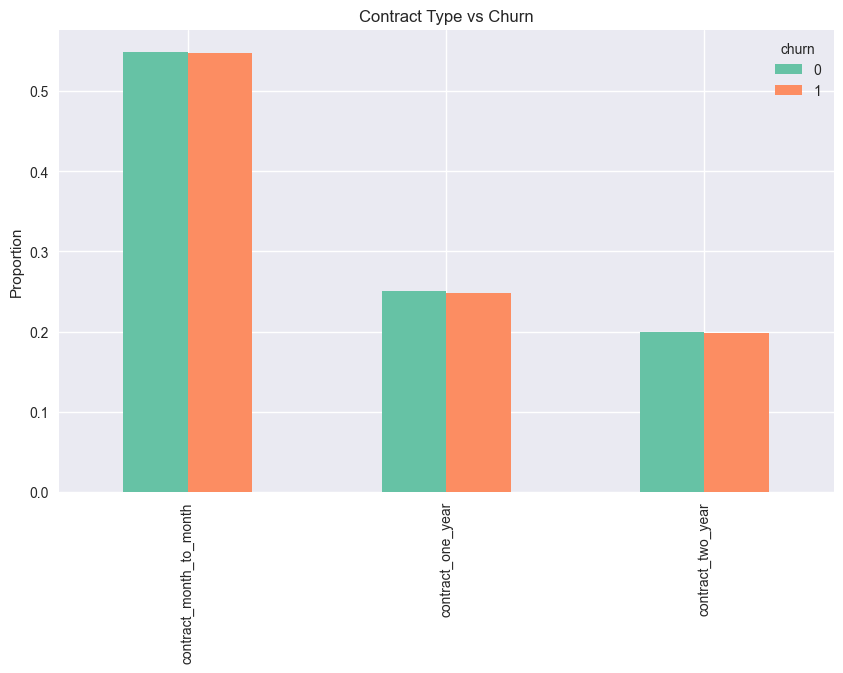

In [34]:
contract_cols = [
    "contract_month_to_month",
    "contract_one_year",
    "contract_two_year"
]

df_contract = df[contract_cols + ["churn"]].groupby("churn").mean()

df_contract.T.plot(kind="bar")
plt.title("Contract Type vs Churn")
plt.ylabel("Proportion")
plt.show()


GitHub README

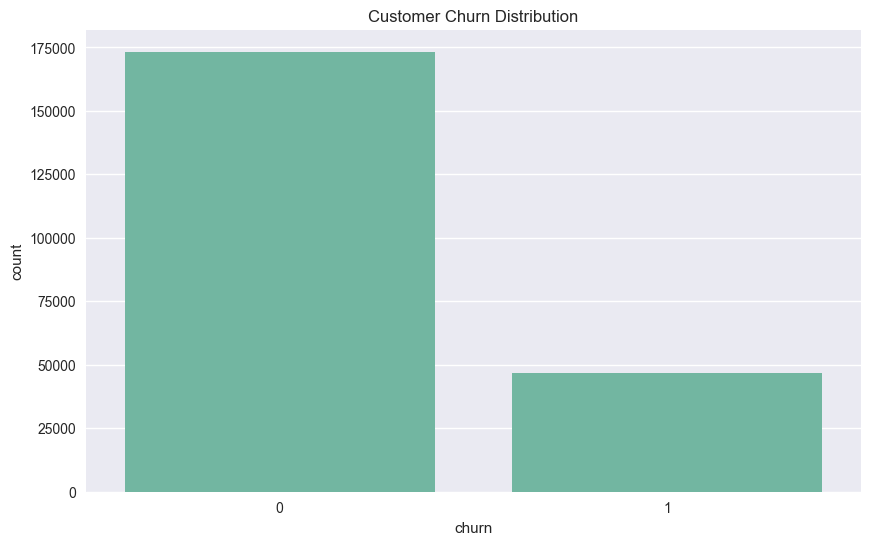

In [35]:
plt.figure(figsize=(10, 6))
sns.countplot(x="churn", data=df)
plt.title("Customer Churn Distribution")
plt.savefig("churn_distribution.png")
plt.show()


-------------------------------------------------------------------------------------

-------------------------------------------------------------------------------------

Logistic regression

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)


Feature–Target split

In [37]:
X = df.drop(columns=["churn"])
y = df["churn"]


Train–Test split

In [40]:
x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


Logistic Regression pipeline

In [41]:
log_reg_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        solver="lbfgs",
        random_state=42
    ))
])
log_reg_pipeline.fit(x_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not wo

Model Training

Predictions

In [42]:
y_pred_lr = log_reg_pipeline.predict(x_test)
y_proba_lr = log_reg_pipeline.predict_proba(x_test)[:, 1]


Evaluation metrics

In [44]:
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_lr))


Accuracy: 0.8027727272727273
Precision: 0.6123423116263211
Recall: 0.1923530041769305
F1 Score: 0.29274653626731867
ROC-AUC: 0.7915798392979078


In [45]:
logreg_accuracy = accuracy_score(y_test, y_pred_lr)
logreg_precision = precision_score(y_test, y_pred_lr)
logreg_recall = recall_score(y_test, y_pred_lr)
logreg_f1 = f1_score(y_test, y_pred_lr)
logreg_roc = roc_auc_score(y_test, y_proba_lr)


Confusion Matrix

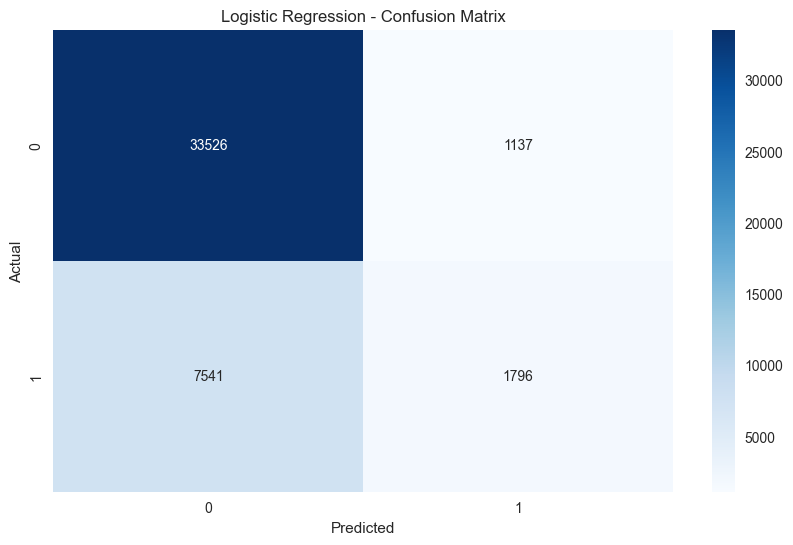

In [47]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Confusion Matrix")
plt.show()


Classification report

In [48]:
print(classification_report(y_test, y_pred_lr))



              precision    recall  f1-score   support

           0       0.82      0.97      0.89     34663
           1       0.61      0.19      0.29      9337

    accuracy                           0.80     44000
   macro avg       0.71      0.58      0.59     44000
weighted avg       0.77      0.80      0.76     44000



-------------------------------------------------------------------------------------

-------------------------------------------------------------------------------------

Random Forest

In [49]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns


Feature–Target split

In [50]:
X = df.drop(columns=["churn"])
y = df["churn"]


Train–Test split

In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


Random Forest model

In [82]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)


Model Training

In [83]:
rf_model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

Predictions

In [84]:
y_proba = rf_model.predict_proba(X_test)[:, 1]
y_pred = (y_proba > 0.35).astype(int)


 Evaluation metrics

In [85]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))


Accuracy: 0.7712727272727272
Precision: 0.4667824179840994
Recall: 0.5470707936167934
F1 Score: 0.5037475345167652
ROC-AUC: 0.7872498723777221


In [86]:
rf_accuracy = accuracy_score(y_test, y_pred)
rf_precision = precision_score(y_test, y_pred)
rf_recall = recall_score(y_test, y_pred)
rf_f1 = f1_score(y_test, y_pred)
rf_roc = roc_auc_score(y_test, y_pred_proba)


Confusion Matrix

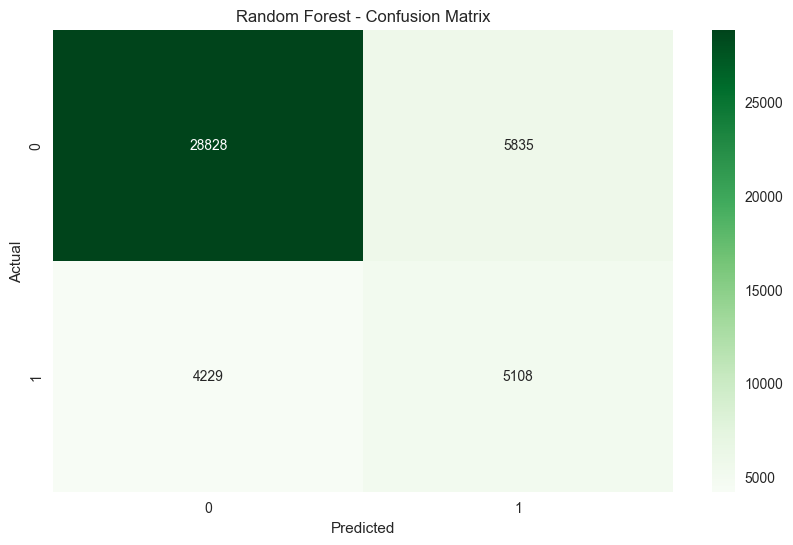

In [87]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest - Confusion Matrix")
plt.show()


Classification report

In [88]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.87      0.83      0.85     34663
           1       0.47      0.55      0.50      9337

    accuracy                           0.77     44000
   macro avg       0.67      0.69      0.68     44000
weighted avg       0.79      0.77      0.78     44000



Feature Importance

In [89]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance.head(10)


tenure_months              0.175664
monthly_charges            0.118933
engagement_score           0.105695
long_term_customer         0.098229
avg_monthly_usage_gb       0.098129
avg_charge_per_gb          0.095439
age                        0.081894
payment_delay_ratio        0.076881
support_tickets_last_6m    0.046956
high_support_contact       0.020456
dtype: float64

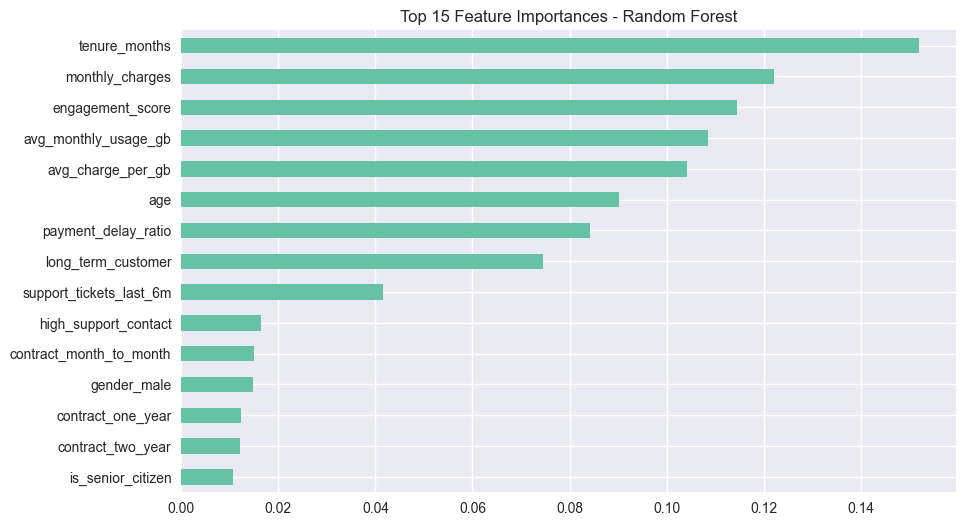

In [60]:
#top 15 features
feature_importance.head(15).plot(kind="barh")
plt.title("Top 15 Feature Importances - Random Forest")
plt.gca().invert_yaxis()
plt.show()


-------------------------------------------------------------------------------------

-------------------------------------------------------------------------------------

XGBoost

In [90]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


Feature–Target split

In [91]:
X = df.drop(columns=["churn"])
y = df["churn"]


Train–Test split

In [92]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


Building XGBoost model

In [93]:
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)


Training XGBoost

In [94]:
xgb_model.fit(X_train, y_train)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

Predictions

In [95]:
y_pred = xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]


Evaluation metrics

In [96]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))


Accuracy: 0.8029772727272727
Precision: 0.5912568306010929
Recall: 0.23176609189247083
F1 Score: 0.3329999230591675
ROC-AUC: 0.795913521669444


In [97]:
xgb_accuracy = accuracy_score(y_test, y_pred)
xgb_precision = precision_score(y_test, y_pred)
xgb_recall = recall_score(y_test, y_pred)
xgb_f1 = f1_score(y_test, y_pred)
xgb_roc = roc_auc_score(y_test, y_pred_proba)


Confusion Matrix

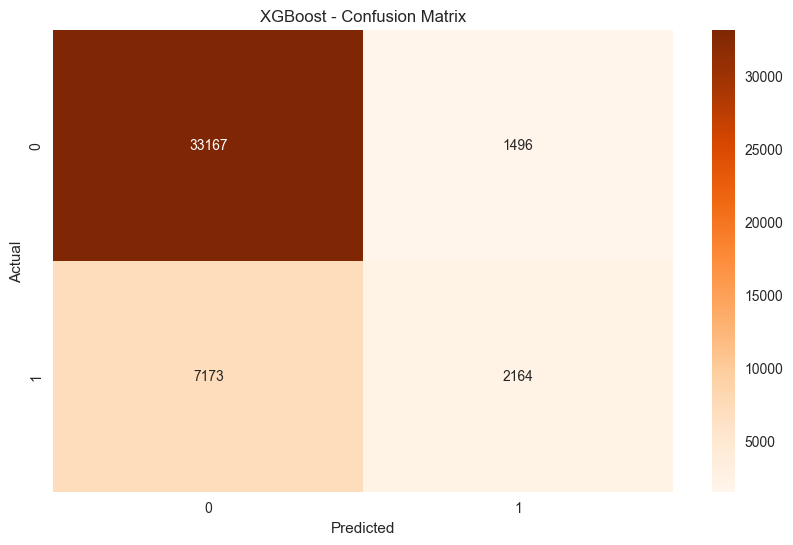

In [98]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost - Confusion Matrix")
plt.show()


Classification report

In [99]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.82      0.96      0.88     34663
           1       0.59      0.23      0.33      9337

    accuracy                           0.80     44000
   macro avg       0.71      0.59      0.61     44000
weighted avg       0.77      0.80      0.77     44000



Feature Importance

In [100]:
feature_importance = pd.Series(
    xgb_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance.head(10)


long_term_customer         0.617200
high_support_contact       0.117927
tenure_months              0.110116
support_tickets_last_6m    0.076836
monthly_charges            0.016610
engagement_score           0.006179
payment_delay_ratio        0.005922
avg_monthly_usage_gb       0.005503
avg_charge_per_gb          0.005436
has_device_protection      0.004805
dtype: float32

Plot top 15

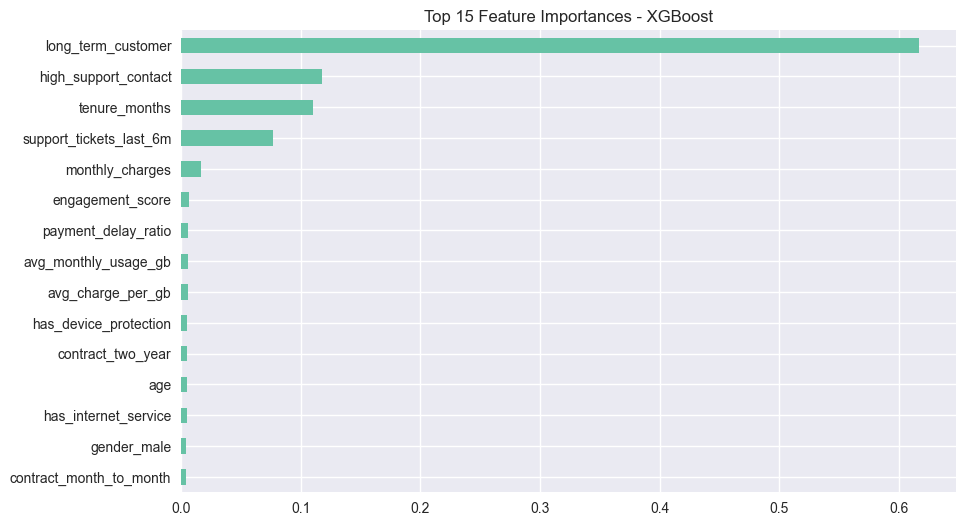

In [101]:
feature_importance.head(15).plot(kind="barh")
plt.title("Top 15 Feature Importances - XGBoost")
plt.gca().invert_yaxis()
plt.show()


-------------------------------------------------------------------------------------

-------------------------------------------------------------------------------------

 MODEL COMPARISON

In [102]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        logreg_accuracy,
        rf_accuracy,
        xgb_accuracy
    ],
    "Precision": [
        logreg_precision,
        rf_precision,
        xgb_precision
    ],
    "Recall": [
        logreg_recall,
        rf_recall,
        xgb_recall
    ],
    "F1 Score": [
        logreg_f1,
        rf_f1,
        xgb_f1
    ],
    "ROC-AUC": [
        logreg_roc,
        rf_roc,
        xgb_roc
    ]
})

model_comparison


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.802773,0.612342,0.192353,0.292747,0.791580
1,Random Forest,0.771273,0.466782,0.547071,0.503748,0.787250
2,XGBoost,0.802977,0.591257,0.231766,0.333000,0.795914


Visual comparison

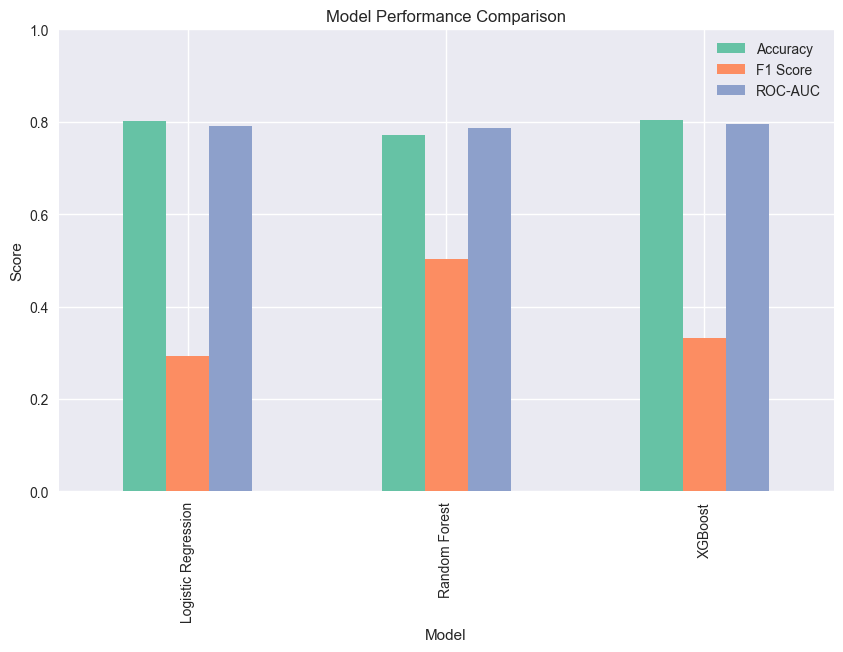

In [103]:
model_comparison.set_index("Model")[["Accuracy", "F1 Score", "ROC-AUC"]].plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.show()


Select final model

In [104]:
best_model = model_comparison.sort_values("ROC-AUC", ascending=False).iloc[0]
best_model


Model         XGBoost
Accuracy     0.802977
Precision    0.591257
Recall       0.231766
F1 Score        0.333
ROC-AUC      0.795914
Name: 2, dtype: object

In [105]:
from sklearn.ensemble import RandomForestClassifier
import joblib

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)


rf_model.fit(X_train, y_train)

joblib.dump(rf_model, "rf_model.pkl")

['rf_model.pkl']

In [106]:
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

In [107]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))


Accuracy: 0.79725
Precision: 0.5499759730898607
Recall: 0.24515368962193423
F1 Score: 0.3391362323135047
ROC-AUC: 0.7872498723777221
